<a href="https://colab.research.google.com/github/ridhimasharma1108/ml-project/blob/main/Another_copy_of_IPL_Prediction_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IPL 1st Inning Score Prediction using Machine Learning
The Dataset contains ball by ball information of the matches played between IPL Teams of **Season 1 to 10**, i.e. from 2008 to 2017.<br/>
This Machine Learning model adapts a Regression Appoach to predict the score of the First Inning of an IPL Match.<br/>
The Dataset can be downloaded from Kaggle from [here](https://www.kaggle.com/yuvrajdagur/ipl-dataset-season-2008-to-2017).<br/>

# Import Necessary Libraries
and Mounting GDrive for importing Dataset

In [ ]:
# Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
np.__version__

'2.0.2'

Mount your Google Drive and save the dataset in the Drive name "data.csv"

In [ ]:
from google.colab import files
uploaded = files.upload()
data = pd.read_csv("IPL_Dataset(2008-2024).csv")

print(f"✅ Dataset successfully imported. Shape: {data.shape}")
print("Sample Data:")
print(data.head())

Saving IPL_Dataset(2008-2024).csv to IPL_Dataset(2008-2024).csv
✅ Dataset successfully imported. Shape: (1073, 18)
Sample Data:
   Match_ID        Date                                              Teams  \
0    335982  2008-04-18  Royal Challengers Bangalore vs Kolkata Knight ...   
1    335983  2008-04-19             Kings XI Punjab vs Chennai Super Kings   
2    335984  2008-04-19               Delhi Daredevils vs Rajasthan Royals   
3    335985  2008-04-20      Mumbai Indians vs Royal Challengers Bangalore   
4    335986  2008-04-20           Kolkata Knight Riders vs Deccan Chargers   

                                        Venue                  Toss_Winner  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali          Chennai Super Kings   
2                            Feroz Shah Kotla             Rajasthan Royals   
3                            Wankhede Stadium               Mumbai Indians   
4            

# Exploratory Data Analysis

In [ ]:
# First 5 Columns Data
data.head()

,Match_ID,Date,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,Win_Type,Win_Margin,First_Innings_Score,Second_Innings_Score,Player_of_Match,Umpire,Umpire1,Umpire2,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores
0,335982,2008-04-18,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,222,82.0,BB McCullum,Asad Rauf,RE Koertzen,J Srinath,61,97,64
1,335983,2008-04-19,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,240,207.0,MEK Hussey,MR Benson,SL Shastri,S Venkataraghavan,53,116,71
2,335984,2008-04-19,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,129,132.0,MF Maharoof,Aleem Dar,GA Pratapkumar,GR Viswanath,40,66,23
3,335985,2008-04-20,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,165,166.0,MV Boucher,SJ Davis,DJ Harper,J Srinath,47,71,47
4,335986,2008-04-20,Kolkata Knight Riders vs Deccan Chargers,Eden Gardens,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,110,112.0,DJ Hussey,BF Bowden,K Hariharan,FM Engineer,39,43,28


In [ ]:
# Describing Numerical Values of the Dataset
data.describe()

,Match_ID,Win_Margin,First_Innings_Score,Second_Innings_Score,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores
count,1.073000e+03,1054.000000,1073.000000,1070.000000,1073.000000,1073.000000,1073.000000
mean,8.941365e+05,17.158444,165.164958,151.918692,46.074557,78.248835,40.841566
std,3.637486e+05,21.762303,31.904238,31.751666,12.007306,18.604148,14.228121
min,3.359820e+05,1.000000,56.000000,2.000000,15.000000,0.000000,0.000000
25%,5.483260e+05,6.000000,145.000000,134.000000,38.000000,66.000000,33.000000
50%,9.809390e+05,8.000000,165.000000,153.000000,46.000000,77.000000,41.000000
75%,1.216540e+06,19.750000,186.000000,172.000000,53.000000,90.000000,50.000000
max,1.426287e+06,146.000000,287.000000,262.000000,125.000000,155.000000,89.000000


In [ ]:
# Information (not-null count and data type) About Each Column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073 entries, 0 to 1072
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Match_ID              1073 non-null   int64  
 1   Date                  1073 non-null   object 
 2   Teams                 1073 non-null   object 
 3   Venue                 1073 non-null   object 
 4   Toss_Winner           1073 non-null   object 
 5   Toss_Decision         1073 non-null   object 
 6   Match_Winner          1073 non-null   object 
 7   Win_Type              1054 non-null   object 
 8   Win_Margin            1054 non-null   float64
 9   First_Innings_Score   1073 non-null   int64  
 10  Second_Innings_Score  1070 non-null   float64
 11  Player_of_Match       1068 non-null   object 
 12  Umpire                1073 non-null   object 
 13  Umpire1               1073 non-null   object 
 14  Umpire2               1073 non-null   object 
 15  Powerplay_Scores     

In [ ]:
# Number of Unique Values in each column
data.nunique()

,0
Match_ID,1073
Date,803
Teams,211
Venue,58
Toss_Winner,19
Toss_Decision,2
Match_Winner,20
Win_Type,2
Win_Margin,98
First_Innings_Score,163


In [ ]:
# Datatypes of all Columns
data.dtypes

,0
Match_ID,int64
Date,object
Teams,object
Venue,object
Toss_Winner,object
Toss_Decision,object
Match_Winner,object
Win_Type,object
Win_Margin,float64
First_Innings_Score,int64


# Data Cleaning

#### Removing Irrelevant Data colunms

In [ ]:
# Names of all columns
data.columns

Index(['Match_ID', 'Date', 'Teams', 'Venue', 'Toss_Winner', 'Toss_Decision',
       'Match_Winner', 'Win_Type', 'Win_Margin', 'First_Innings_Score',
       'Second_Innings_Score', 'Player_of_Match', 'Umpire', 'Umpire1',
       'Umpire2', 'Powerplay_Scores', 'Middle_Overs_Scores',
       'Death_Overs_Scores'],
      dtype='object')

Here, we can see that columns _['mid', 'date', 'venue', 'batsman', 'bowler', 'striker', 'non-striker']_ won't provide any relevant information for our model to train

In [ ]:
# Drop columns that don’t affect match prediction
irrelevant = [
    'Match_ID', 'Date', 'Player_of_Match', 'Umpire',
    'Win_Type', 'Win_Margin',
    'Powerplay_Scores', 'Middle_Overs_Scores', 'Death_Overs_Scores'
]
print(f"Before Removing Irrelevant Columns : {data.shape}")
data = data.drop(columns=irrelevant, errors='ignore')
print(f"After Removing Irrelevant Columns : {data.shape}")
data.head()


Before Removing Irrelevant Columns : (1073, 18)
After Removing Irrelevant Columns : (1073, 9)


,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,First_Innings_Score,Second_Innings_Score,Umpire1,Umpire2
0,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,222,82.0,RE Koertzen,J Srinath
1,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,240,207.0,SL Shastri,S Venkataraghavan
2,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,129,132.0,GA Pratapkumar,GR Viswanath
3,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,165,166.0,DJ Harper,J Srinath
4,Kolkata Knight Riders vs Deccan Chargers,Eden Gardens,Deccan Chargers,bat,Kolkata Knight Riders,110,112.0,K Hariharan,FM Engineer


#### Keeping only Consistent Teams
(teams that never change even in current season)

In [ ]:
# Define Consistent Teams
const_teams = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
              'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
              'Delhi Daredevils', 'Sunrisers Hyderabad']

In [ ]:

if 'Teams' in data.columns:
    data[['Team1', 'Team2']] = data['Teams'].str.split(' vs ', expand=True)

const_teams = [
    'Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
    'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
    'Delhi Daredevils', 'Sunrisers Hyderabad'
]

print(f"\nBefore Removing Inconsistent Teams: {data.shape}")

data = data[
    (data['Team1'].isin(const_teams)) &
    (data['Team2'].isin(const_teams))
]

print(f"After Removing Inconsistent Teams: {data.shape}")

data['Team1'] = data['Team1'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
})
data['Team2'] = data['Team2'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
})

print("\n✅ Consistent Teams Present After Cleaning:")
print(sorted(data['Team1'].unique()))
data.drop_duplicates(inplace=True)
data.reset_index(drop=True, inplace=True)
print("\nFinal Cleaned Data Shape:", data.shape)
data.head()



Before Removing Inconsistent Teams: (1073, 11)
After Removing Inconsistent Teams: (688, 11)

✅ Consistent Teams Present After Cleaning:
['Chennai Super Kings', 'Delhi Capitals', 'Kolkata Knight Riders', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']

Final Cleaned Data Shape: (688, 11)


/tmp/ipython-input-1217852376.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Team1'] = data['Team1'].replace({
/tmp/ipython-input-1217852376.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Team2'] = data['Team2'].replace({
/tmp/ipython-input-1217852376.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-cop

,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,First_Innings_Score,Second_Innings_Score,Umpire1,Umpire2,Team1,Team2
0,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,222,82.0,RE Koertzen,J Srinath,Royal Challengers Bangalore,Kolkata Knight Riders
1,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,240,207.0,SL Shastri,S Venkataraghavan,Punjab Kings,Chennai Super Kings
2,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,129,132.0,GA Pratapkumar,GR Viswanath,Delhi Capitals,Rajasthan Royals
3,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,165,166.0,DJ Harper,J Srinath,Mumbai Indians,Royal Challengers Bangalore
4,Rajasthan Royals vs Kings XI Punjab,Sawai Mansingh Stadium,Kings XI Punjab,bat,Rajasthan Royals,166,168.0,RB Tiffin,S Venkataraghavan,Rajasthan Royals,Punjab Kings


#### Remove First 5 Overs of every match

In [ ]:
print("Available Columns:\n", data.columns)
possible_cols = ['overs', 'Over', 'over_no', 'ball', 'Ball']
col_name = None
for col in possible_cols:
    if col in data.columns:
        col_name = col
        break
if col_name:
    print(f"\n✅ Using '{col_name}' column to remove first 5 overs")
    print(f'Before Removing Overs : {data.shape}')
    data = data[data[col_name] >= 5.0]
    print(f'After Removing Overs : {data.shape}')
    print(data.head())
else:
    print("⚠️ No column related to 'overs' found. Please verify your dataset columns.")

Available Columns:
 Index(['Teams', 'Venue', 'Toss_Winner', 'Toss_Decision', 'Match_Winner',
       'First_Innings_Score', 'Second_Innings_Score', 'Umpire1', 'Umpire2',
       'Team1', 'Team2'],
      dtype='object')
⚠️ No column related to 'overs' found. Please verify your dataset columns.


Plotting a Correlation Matrix of current data

Numeric Columns: ['First_Innings_Score', 'Second_Innings_Score']


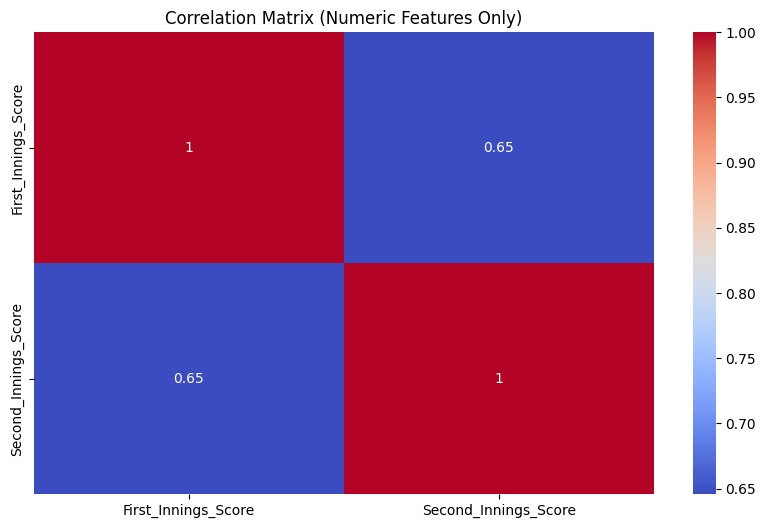

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = data.select_dtypes(include=['int64', 'float64'])
print("Numeric Columns:", numeric_data.columns.tolist())
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()


# Data Preprocessing and Encoding

#### Performing Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols_to_encode = ['batting_team', 'bowling_team']

available_cols = [col for col in cols_to_encode if col in data.columns]

print("Columns available for encoding:", available_cols)

for col in available_cols:
    data[col] = le.fit_transform(data[col])

data.head()


Columns available for encoding: []


,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,First_Innings_Score,Second_Innings_Score,Umpire1,Umpire2,Team1,Team2
0,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,222,82.0,RE Koertzen,J Srinath,Royal Challengers Bangalore,Kolkata Knight Riders
1,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,240,207.0,SL Shastri,S Venkataraghavan,Punjab Kings,Chennai Super Kings
2,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,129,132.0,GA Pratapkumar,GR Viswanath,Delhi Capitals,Rajasthan Royals
3,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,165,166.0,DJ Harper,J Srinath,Mumbai Indians,Royal Challengers Bangalore
4,Rajasthan Royals vs Kings XI Punjab,Sawai Mansingh Stadium,Kings XI Punjab,bat,Rajasthan Royals,166,168.0,RB Tiffin,S Venkataraghavan,Rajasthan Royals,Punjab Kings


#### Performing One Hot Encoding and Column Transformation

In [ ]:
from sklearn.compose import ColumnTransformer
columnTransformer = ColumnTransformer([('encoder',
                                        OneHotEncoder(),
                                        [0, 1])],
                                      remainder='passthrough')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols_to_encode = ['batting_team', 'bowling_team']  # <-- yahan apne sahi naam daalna
available_cols = [col for col in cols_to_encode if col in data.columns]

print("Columns available for encoding:", available_cols)

for col in available_cols:
    data[col] = le.fit_transform(data[col])

data.head()


Columns available for encoding: []


,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,First_Innings_Score,Second_Innings_Score,Umpire1,Umpire2,Team1,Team2
0,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,222,82.0,RE Koertzen,J Srinath,Royal Challengers Bangalore,Kolkata Knight Riders
1,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,240,207.0,SL Shastri,S Venkataraghavan,Punjab Kings,Chennai Super Kings
2,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,129,132.0,GA Pratapkumar,GR Viswanath,Delhi Capitals,Rajasthan Royals
3,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,165,166.0,DJ Harper,J Srinath,Mumbai Indians,Royal Challengers Bangalore
4,Rajasthan Royals vs Kings XI Punjab,Sawai Mansingh Stadium,Kings XI Punjab,bat,Rajasthan Royals,166,168.0,RB Tiffin,S Venkataraghavan,Rajasthan Royals,Punjab Kings


Save the Numpy Array in a new DataFrame with transformed columns

In [ ]:
cols = ['batting_team_Chennai Super Kings', 'batting_team_Delhi Daredevils', 'batting_team_Kings XI Punjab',
              'batting_team_Kolkata Knight Riders', 'batting_team_Mumbai Indians', 'batting_team_Rajasthan Royals',
              'batting_team_Royal Challengers Bangalore', 'batting_team_Sunrisers Hyderabad',
              'bowling_team_Chennai Super Kings', 'bowling_team_Delhi Daredevils', 'bowling_team_Kings XI Punjab',
              'bowling_team_Kolkata Knight Riders', 'bowling_team_Mumbai Indians', 'bowling_team_Rajasthan Royals',
              'bowling_team_Royal Challengers Bangalore', 'bowling_team_Sunrisers Hyderabad', 'runs', 'wickets', 'overs',
       'runs_last_5', 'wickets_last_5', 'total']
df = pd.DataFrame(data, columns=cols)

In [ ]:
# Visualize Encoded Data
df.head()

,batting_team_Chennai Super Kings,batting_team_Delhi Daredevils,batting_team_Kings XI Punjab,batting_team_Kolkata Knight Riders,batting_team_Mumbai Indians,batting_team_Rajasthan Royals,batting_team_Royal Challengers Bangalore,batting_team_Sunrisers Hyderabad,bowling_team_Chennai Super Kings,bowling_team_Delhi Daredevils,...,bowling_team_Mumbai Indians,bowling_team_Rajasthan Royals,bowling_team_Royal Challengers Bangalore,bowling_team_Sunrisers Hyderabad,runs,wickets,overs,runs_last_5,wickets_last_5,total
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Model Building

## Prepare Train and Test Splits

In [ ]:
features = df.drop(['total'], axis=1)
labels = df['total']

In [ ]:
# Perform 80 : 20 Train-Test split
from sklearn.model_selection import train_test_split
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.20, shuffle=True)
print(f"Training Set : {train_features.shape}\nTesting Set : {test_features.shape}")
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# ✅ Step 5: Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training Set : (550, 21)
Testing Set : (138, 21)


## Model Algorithms
Training and Testing on different Machine Learning Algorithms for the best algorithm to choose from

In [ ]:
# Keeping track of model perfomances
models = dict()



#### 1. Decision Tree Regressor

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("\n🌳 Decision Tree Regressor:")
print("MSE:", mse_tree)
print("R2 Score:", r2_tree)
models["Decision Tree"] = r2_tree * 100



🌳 Decision Tree Regressor:
MSE: 1333.3623188405797
R2 Score: -0.36678819937105


In [ ]:
# ✅ Evaluate Model
train_score_tree = tree.score(X_train, y_train) * 100
test_score_tree = tree.score(X_test, y_test) * 100

print(f"Train Score : {train_score_tree:.2f}%")
print(f"Test Score  : {test_score_tree:.2f}%")

models["Decision Tree"] = test_score_tree


Train Score : 100.00%
Test Score  : -36.68%


In [ ]:
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
import numpy as np

print("---- Decision Tree Regressor - Model Evaluation ----")
print("Mean Absolute Error (MAE):", mae(y_test, tree.predict(X_test)))
print("Mean Squared Error (MSE):", mse(y_test, tree.predict(X_test)))
print("Root Mean Squared Error (RMSE):", np.sqrt(mse(y_test, tree.predict(X_test))))


---- Decision Tree Regressor - Model Evaluation ----
Mean Absolute Error (MAE): 22.507246376811594
Mean Squared Error (MSE): 1333.3623188405797
Root Mean Squared Error (RMSE): 36.51523406525802


# Predictions

In [ ]:
import numpy as np

def predict_score(team1, team2, venue, toss_winner, toss_decision, model):
    # Encoding manually for teams
    teams = ['Chennai Super Kings', 'Delhi Daredevils', 'Kings XI Punjab',
             'Kolkata Knight Riders', 'Mumbai Indians', 'Rajasthan Royals',
             'Royal Challengers Bangalore', 'Sunrisers Hyderabad']

    # One-hot encoding for Team1
    team1_encoded = [1 if team1 == t else 0 for t in teams]

    # One-hot encoding for Team2
    team2_encoded = [1 if team2 == t else 0 for t in teams]

    # Combine features
    input_data = team1_encoded + team2_encoded + [venue, toss_winner, toss_decision]

    # Convert to numpy array
    input_data = np.array([input_data])

    # Predict
    prediction = model.predict(input_data)
    return int(round(prediction[0]))


**Test 1**
- Batting Team : **Mumbai Indians**
- Bowling Team : **Kings XI Punjab**
- Final Score : **176/7**

```
# This is formatted as code
```



In [ ]:
print(X.columns)
input_data = pd.DataFrame([{
    'Teams': 4,  # encoded value
    'Venue': 2,
    'Toss_Winner': 1,
    'Toss_Decision': 0,
    'Match_Winner': 3,
    'Second_Innings_Score': 180,
    'Umpire1': 5,
    'Umpire2': 7,
    'Team1': 4,
    'Team2': 2
}])
pred = tree.predict(input_data)
print("Predicted First Innings Score:", pred[0])


Index(['Teams', 'Venue', 'Toss_Winner', 'Toss_Decision', 'Match_Winner',
       'Second_Innings_Score', 'Umpire1', 'Umpire2', 'Team1', 'Team2'],
      dtype='object')
Predicted First Innings Score: 178.0
